Ultralytics provides a conveninent interface to using YOLO and related models
- Pro: Easy and quick to get going
- Con: Copyleft licence unless you pay for a commercial licence (You need to open source any code that uses ultralytics models, not really a concern for academic purposes, but important if you want to develop a product)

Some models are available on their own, however the naming is a bit of a free for all.





Install Ultralytics


In [ ]:
!pip install ultralytics


Ultralytics Yolo Models

- **YOLOv8**
  -  Good place to start
  -  **Supports**: Detection, segmentation, pose, oriented detection, classification

- **YOLOv9**
  - Improvements to object detection
  - **Supports**: Detection

- **YOLOv10**
  - Improvement performance of real time detection
  - **Supports**: Detection, Segmentation

- **YOLOv11**
   - **Improved** performance supports all tasks
   - Supports: Detection, Segmentation, pose, oriented detection, classification


**What to choose?**
- YoloV8 and YoloV11 are capable of all standard vision tasks, yolov11 is newer and by newer i mean it came out a month ago as of writing this lab.
- Yolov9, v10 and v11 all came out in the same year (2024).
- The interface to use yolo is fairly similar across versions, so any examples you find that use v8 should work on v11. (Trying to use 8 might just cause ultralytics to download 11 anyways)


**Ultralytics** has other models as well in particular SAM, SAM2, FastSAM.
- **Note**: Not all models are created by Ultralytics, due the nature of software licences you may be able to find the same model outside the Ultralytics ecosystem.
- **Example**: SAM is a model created by facebook, it's open source and you can use it in commercial software if you use it from their repo, however if you use it through ultralytics you have to follow the APGL licence.
- **Key point**: Architectures usually arent licenced, however specific implementations can be.



In [ ]:
from ultralytics import YOLO
# Load a COCO-pretrained YOLOv8n model
model = YOLO("yolov8n.pt")

# Display model information (optional)
model.info()

# Train the model on the COCO8 example dataset for 100 epochs
results = model.train(data="coco8.yaml", epochs=100, imgsz=640)




In [ ]:
# Run inference with the YOLOv8n model on the 'bus.jpg' image
results = model("/content/bus.jpg")

In [ ]:
from ultralytics import YOLO
# Load a COCO-pretrained YOLOv8n model
model = YOLO("/content/yolo11n.pt")

# Display model information (optional)
model.info()

# Train the model on the COCO8 example dataset for 100 epochs
results = model.train(data="coco8.yaml", epochs=100, imgsz=640)


In [ ]:
# Run inference with the YOLOv8n model on the 'bus.jpg' image
results = model("/content/bus.jpg")

In [ ]:
import cv2
import numpy as np

# Get the first result (assuming single image input)
result = results[0]

# Read the original image
img = cv2.imread('/content/bus.jpg')

# Get bounding boxes, class IDs, and confidence scores
boxes = result.boxes.xyxy.cpu().numpy().astype(int)
class_ids = result.boxes.cls.cpu().numpy().astype(int)
confidences = result.boxes.conf.cpu().numpy()

# Draw bounding boxes and labels on the image
for box, class_id, confidence in zip(boxes, class_ids, confidences):
    x1, y1, x2, y2 = box
    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    label = f"{result.names[class_id]} {confidence:.2f}"
    cv2.putText(img, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

Another benefit of using Ultralytics is that it produces several useful evaluation files and images.
- Files and weights are stored in /runs/detect/train/
- Each time you run training a new folder is created
 - This can get messy, as the folder is created when training starts, regardless of how much it progresses.
 - Mainly a problem if you want to display the latest training results

In [ ]:
folder_path = '/content/runs/detect/train'
import os
image_files = [f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

In [ ]:
for image_file in image_files:
    image_path = os.path.join(folder_path, image_file)
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 8))
    plt.imshow(img_rgb)
    plt.title(image_file)
    plt.axis('off')
    plt.show()

Example results


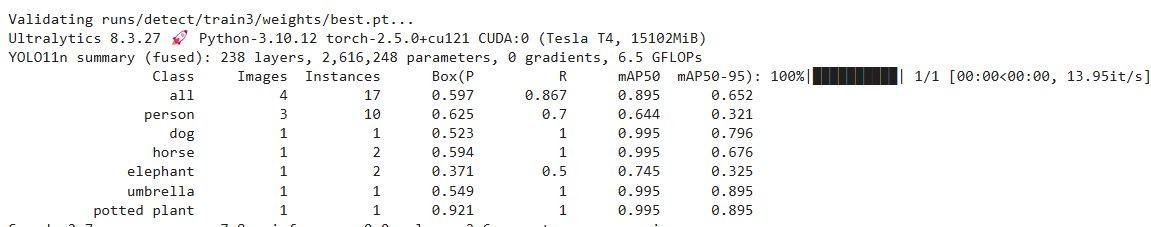

Overall Performance (all)
- **P (Precision):** 0.597 - This indicates that 59.7% of all object detections across all classes were correct.
- **R (Recall):** 0.867 - The model successfully identified 86.7% of all objects present in the images.
- **mAP50**: 0.895 - The mean Average Precision at an IoU threshold of 0.5 is 89.5%, indicating good overall performance for "easier" detections.
- **mAP50-95**: 0.652 - The average mAP across IoU thresholds from 0.5 to 0.95 is 65.2%, showing how well the model performs across various detection difficulties.

**Dog**
- P: 0.523 - 52.3% of dog detections were accurate.
- R: 1.0 - The model detected all dogs in the images.
- mAP50: 0.995 - Excellent performance for dog detection at IoU 0.5.
- mAP50-95: 0.796 - Good performance across various IoU thresholds, indicating
precise localization.

**Horse**
- P: 0.594 - 59.4% of horse detections were correct.
- R: 1.0 - All horses in the images were detected.
- mAP50: 0.995 - Excellent performance for horse detection at IoU 0.5.
- mAP50-95: 0.676 - Good performance across stricter IoU thresholds.

**Elephant**
- P: 0.371 - Only 37.1% of elephant detections were accurate, **indicating many false positives.**
- R: 0.5 - The model **detected half** of the elephants in the images.
- mAP50: 0.745 - Decent performance for elephant detection at IoU 0.5.
- mAP50-95: 0.325 - Lower performance across stricter IoU thresholds, suggesting less precise localization.

**Umbrella**
- P: 0.549 - 54.9% of umbrella detections were correct.
- R: 1.0 - All umbrellas in the images were detected.
- mAP50: 0.995 - Excellent performance for umbrella detection at IoU 0.5.
- mAP50-95: 0.895 - Very good performance across various IoU thresholds, indicating precise localization.

**Potted Plant**
- P: 0.921 - 92.1% of potted plant detections were accurate, showing high precision.
- R: 1.0 - All potted plants in the images were detected.
- mAP50: 0.995 - Excellent performance for potted plant detection at IoU 0.5.
- mAP50-95: 0.895 - Very good performance across various IoU thresholds, indicating precise localization.

**mAP50** - mean Average Precision at IoU threshold 0.5
- A measure of how well the predicted bounding boxes overlap with the actual (ground truth) bounding boxes.
- The "50" in mAP@50 refers to an IoU (Intersection over Union) threshold of 0.5 This means that for a prediction to be considered a true positive, the IoU between the predicted box and the ground truth box must be at least 50%.
- Intersection over Union (IoU) is a metric that measures how much the predicted bounding box overlaps with the actual bounding box. An IoU of 1 means a perfect overlap, while 0 means no overlap.
- The "mAP" part stands for mean Average Precision. Precision in object detection is calculated based on the ratio of true positives to the sum of true positives and false positives, giving a sense of accuracy in terms of correct detections.

**mAP95**
- Same as above except the threshold is .95